In [1]:
!pip install faiss-cpu timm albumentations

In [2]:
import json

with open('/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/train_results/annotations.json', 'r') as f:
    annotations = json.load(f)

annotations_dict = {}
for annot in annotations:
    annotations_dict[f"{annot['image_path']}_{annot['image_id']}"] = annot

In [3]:
len(annotations_dict)

37801

In [4]:
list(annotations_dict.keys())[:2]

['/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/리조트/995453.jpg_1',
 '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/페미닌/868254.jpg_0']

In [5]:
annotations_dict['/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/리조트/995453.jpg_1']

{'image_path': '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/리조트/995453.jpg',
 'image_id': 1,
 'box': [297, 417, 481, 706],
 'detail_category': '티셔츠',
 'color': '핑크',
 'fit': '노멀',
 'length': '노멀'}

In [6]:
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import pickle
import json

vecto_dir = '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/vectors'

normalizer = Normalizer(norm='l2')
pca_path = os.path.join(vecto_dir, 'pca_model.pkl')
with open(pca_path, 'rb') as f:
    pca = pickle.load(f)

feature_path = os.path.join(vecto_dir, 'feature_map.json')
with open(feature_path, 'r') as f:
    feature_map = json.load(f)

image_path_id_list = []
feature_list = []
for key, value in feature_map.items():
    image_path_id_list.append(key)
    feature_list.append(value)

norm_feature_list = normalizer.fit_transform(feature_list)

com_feature_list = pca.transform(norm_feature_list)

In [7]:
com_feature_list[0]

array([-3.43529395e-01, -4.75757542e-02, -2.60033233e-02, -1.64515535e-01,
       -2.00302081e-01, -7.90675802e-03,  1.70538787e-01, -1.63789155e-01,
       -4.08800244e-02, -3.40656161e-01,  1.53394182e-01, -1.27233647e-01,
       -1.65045431e-01, -5.36765546e-03, -1.17283967e-01, -8.11498077e-02,
       -3.09853821e-02, -3.91987374e-02,  8.23520478e-02,  8.03887906e-02,
        5.31040839e-02,  5.16019764e-03, -5.14647587e-02, -1.16537643e-02,
       -2.65040819e-02,  7.53411408e-02,  2.82433891e-02,  1.18997806e-01,
       -7.58613730e-02,  2.41957521e-02,  7.67816295e-02, -9.76832652e-02,
        2.45762063e-02,  3.08306177e-02, -1.43497363e-02,  2.26681804e-02,
        2.51046042e-02,  2.57193950e-02,  2.72189914e-02,  1.10123347e-02,
        1.22815089e-01,  2.17044952e-02,  1.88911139e-03, -5.16183009e-02,
       -1.02510058e-01, -6.42530037e-02, -4.46625196e-02,  5.97901815e-02,
       -3.38474938e-02, -2.59527802e-02,  2.88900750e-02, -3.29489864e-02,
       -5.92240184e-02,  

In [8]:
com_feature_list[0].shape

(128,)

In [9]:
image_path_id_list[0]

'/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/스트리트/209374.jpg_1'

In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def draw_image(images, distances):
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))

    for i, ax in enumerate(axs.flat):
        if i >= len(images):
            break
        ax.imshow(images[i])
        ax.set_title(distances[i])

    plt.tight_layout()
    plt.show()

In [11]:
com_feature_list[0].shape[0]

128

In [12]:
import os
import faiss
import random

index_dir = '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/index'
os.makedirs(index_dir, exist_ok=True)

with open(os.path.join(index_dir, 'image_path_id_list.json'), 'w') as f:
    json.dump(image_path_id_list, f, ensure_ascii=False, indent='\t')

d = com_feature_list[0].shape[0]

index = faiss.IndexFlatL2(d)

index.add(com_feature_list)

faiss.write_index(index, os.path.join(index_dir, 'flat_index.index'))

k = 8
random_idx = random.randint(0, len(com_feature_list))
query_vector = com_feature_list[random_idx].reshape(1, -1)

distances, indices = index.search(query_vector, k)

In [13]:
print(f"유사한 이미지 목록: {indices[0]}")
print(f"유사한 이미지의 거리 값: {distances[0]}")

유사한 이미지 목록: [3738 3162 2524 2203 3456 1985 3487  469]
유사한 이미지의 거리 값: [0.         0.09368512 0.11381541 0.11502884 0.12977627 0.15277413
 0.16067666 0.16623366]


In [14]:
image_path_id_list[3579]

'/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/모던/797604.jpg_0'

In [15]:
from PIL import Image

margin = 0.1
image_list = []
dist_list = []

for idx, dist in zip(indices[0], distances[0]):
    annot = annotations_dict[image_path_id_list[idx]]
    image_path = annot['image_path']
    image = Image.open(image_path). convert('RGB')
    box = annot['box']

    w = box[2] - box[0]
    h = box[3] - box[1]

    new_box = [
        int(box[0] - w * margin),
        int(box[1] - h * margin),
        int(box[2] + w * margin),
        int(box[3] + h * margin),
    ]
    cropped_image = image.crop(new_box)
    image_list.append(cropped_image)
    dist_list.append(dist)

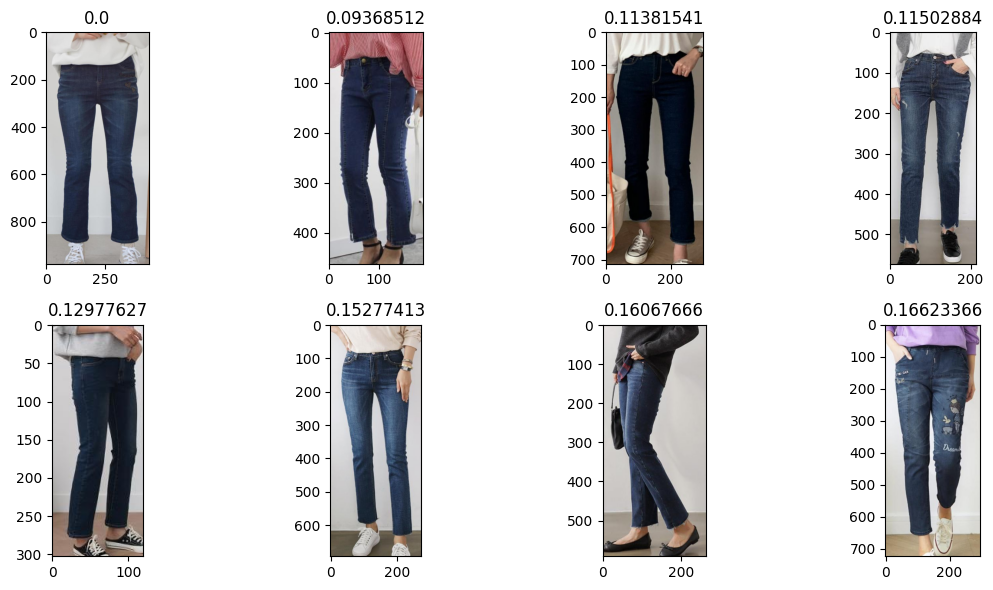

In [16]:
draw_image(image_list, dist_list)

In [17]:
com_feature_list.shape[0]

4352

In [18]:
import numpy as np

d = com_feature_list[0].shape[0]
nlist = int(np.sqrt(com_feature_list.shape[0]))
quantizer = faiss.IndexFlatL2(d)
index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)

index.train(com_feature_list)

index.add(com_feature_list)

assert index.is_trained

faiss.write_index(index, os.path.join(index_dir, 'ivf_index.index'))

k = 8
index.nprobe = 10

random_idx = random.randint(0, len(com_feature_list))
query_vector = com_feature_list[random_idx].reshape(1, -1)

distances, indices = index.search(query_vector, k)

In [19]:
from PIL import Image

margin = 0.1
image_list = []
dist_list = []

for idx, dist in zip(indices[0], distances[0]):
    annot = annotations_dict[image_path_id_list[idx]]
    image_path = annot['image_path']
    image = Image.open(image_path). convert('RGB')
    box = annot['box']

    w = box[2] - box[0]
    h = box[3] - box[1]

    new_box = [
        int(box[0] - w * margin),
        int(box[1] - h * margin),
        int(box[2] + w * margin),
        int(box[3] + h * margin),
    ]
    cropped_image = image.crop(new_box)
    image_list.append(cropped_image)
    dist_list.append(dist)

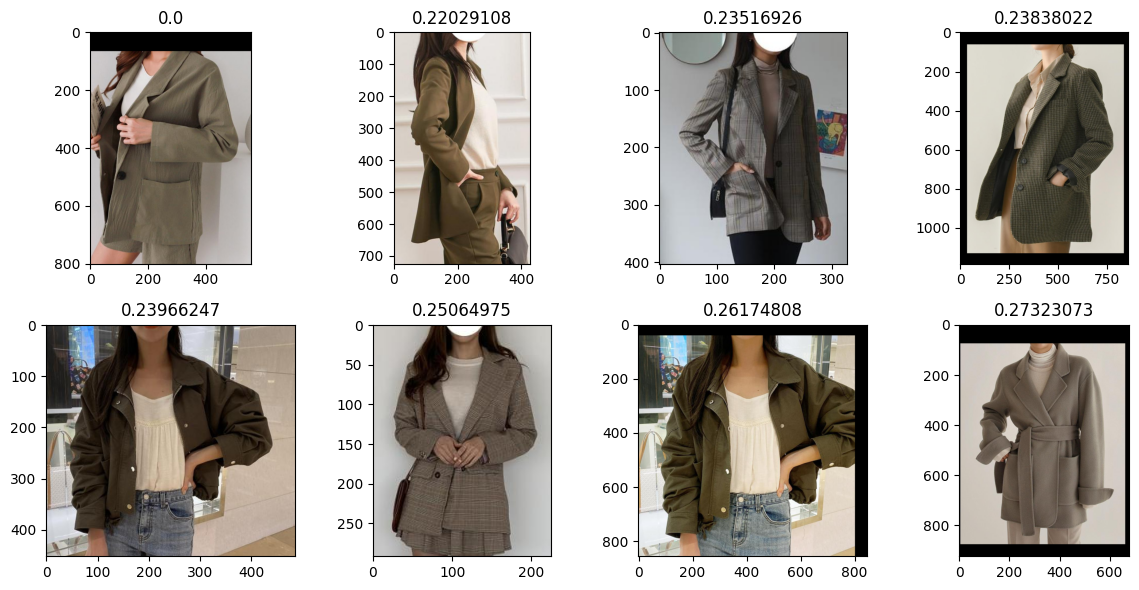

In [20]:
draw_image(image_list, dist_list)

In [21]:
com_feature_list.shape

(4352, 128)

In [22]:
com_feature_list[0].shape[0]

128

In [23]:
com_feature_list.shape[1]

128

In [24]:
d = com_feature_list.shape[1]
M = 32
index = faiss.IndexHNSWFlat(d, M)

index.add(com_feature_list)

faiss.write_index(index, os.path.join(index_dir, 'hnsw_index.index'))

random_idx = random.randint(0, len(com_feature_list))
query_vector = com_feature_list[random_idx].reshape(1, -1)

distances, indices = index.search(query_vector, k)

In [25]:
from PIL import Image

margin = 0.1
image_list = []
dist_list = []

for idx, dist in zip(indices[0], distances[0]):
    annot = annotations_dict[image_path_id_list[idx]]
    image_path = annot['image_path']
    image = Image.open(image_path). convert('RGB')
    box = annot['box']

    w = box[2] - box[0]
    h = box[3] - box[1]

    new_box = [
        int(box[0] - w * margin),
        int(box[1] - h * margin),
        int(box[2] + w * margin),
        int(box[3] + h * margin),
    ]
    cropped_image = image.crop(new_box)
    image_list.append(cropped_image)
    dist_list.append(dist)

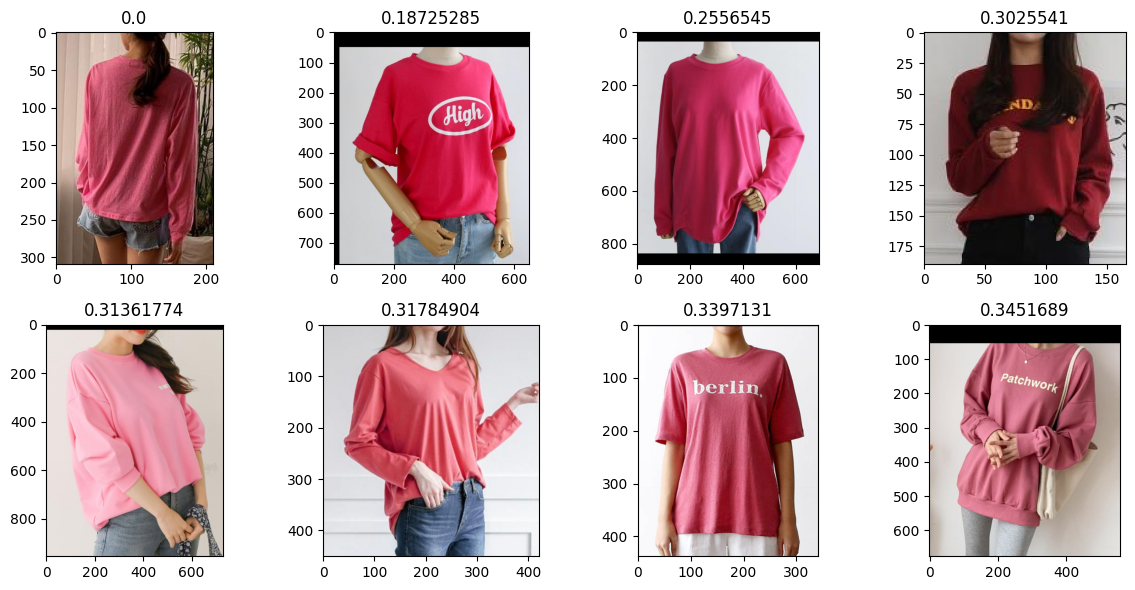

In [26]:
draw_image(image_list, dist_list)

In [27]:
batch_size = 64
split_point = len(com_feature_list) // batch_size

In [28]:
len(com_feature_list)

4352

In [29]:
split_point

68

In [31]:
import time
from tqdm.notebook import tqdm

batch_size = 64
split_point = len(com_feature_list)

index = faiss.read_index('/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/index/flat_index.index')
st_time = time.time()
for i in tqdm(range(split_point)):
    if i == split_point - 1:
        batch_features = com_feature_list[i * batch_size:]
    else:
        batch_features = com_feature_list[i * batch_size: (i+1)*batch_size]
    index.search(batch_features, 50)
print(f"완전 탐색 시간: {time.time() - st_time}")

index = faiss.read_index('/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/index/ivf_index.index')
st_time = time.time()
for i in tqdm(range(split_point)):
    if i == split_point - 1:
        batch_features = com_feature_list[i * batch_size:]
    else:
        batch_features = com_feature_list[i * batch_size: (i+1)*batch_size]
    index.search(batch_features, 50)
print(f"ivf 탐색 시간: {time.time() - st_time}")

index = faiss.read_index('/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/index/hnsw_index.index')
st_time = time.time()
for i in tqdm(range(split_point)):
    if i == split_point - 1:
        batch_features = com_feature_list[i * batch_size:]
    else:
        batch_features = com_feature_list[i * batch_size: (i+1)*batch_size]
    index.search(batch_features, 50)
print(f"ivf 탐색 시간: {time.time() - st_time}")

  0%|          | 0/4352 [00:00<?, ?it/s]

완전 탐색 시간: 0.8819186687469482


  0%|          | 0/4352 [00:00<?, ?it/s]

ivf 탐색 시간: 0.1328880786895752


  0%|          | 0/4352 [00:00<?, ?it/s]

ivf 탐색 시간: 0.23979616165161133


In [46]:
!FLASK_ENV=development FLASK_APP='/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/part3_chapter03_app/matching_app.py' flask run

/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/part3_chapter03_app/matching_app.py:67: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  A.LongestMaxSize(max_size=224,
/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/part3_chapter03_app/matching_app.py:69: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=224,
 * Serving Flask app '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/part3_chapter03_app/matching_app.py'
 * Debug mode: off
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
Exception ignored in atexit callback: <function dump_compile_times at 0x7814ba877240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/utils.py", line 860, in dump_compile_times
    log.info(compile_times(repr="str", aggregate=T

In [47]:
import subprocess

flask_command = ['python3', '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/part3_chapter03_app/matching_app.py']

flask_process = subprocess.Popen(flask_command)

In [48]:
import requests
import io
from PIL import Image
from tqdm.notebook import tqdm
import numpy as np

image = Image.open('/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/similar_fashion_products/part3_chapter03_app/test_image.jpg').convert('RGB')
image_bytes = io.BytesIO()
image.save(image_bytes, format='JPEG')

files = {'file': ('test_image.jpg', image_bytes.getvalue())}

resp = requests.post(url="http://localhost:5000/predict", files=files)

results = resp.json()

In [49]:
flask_process.terminate()

In [50]:
results.keys()

dict_keys(['distances', 'matched_files'])

In [51]:
results

{'distances': [0.5036724805831909,
  0.5249714851379395,
  0.5252295732498169,
  0.5332376956939697,
  0.5455272197723389,
  0.5517793893814087,
  0.5595988631248474,
  0.5625854730606079],
 'matched_files': ['/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/스트리트/125144.jpg_0',
  '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/스트리트/650474.jpg_1',
  '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/스트리트/378411.jpg_0',
  '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/스트리트/911207.jpg_1',
  '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/모던/226155.jpg_1',
  '/content/drive/MyDrive/Colab Notebooks/fast_campus_image_processing/Datasets/part3_chapter03/images/리조트/1120753.jpg_1',
  '/content/drive/MyDrive/Colab Not

In [53]:
distances = results['distances']
matched_files = results['matched_files']

margin = 0.1
image_list = []
dist_list = []

for file, dist in zip(matched_files, distances):
    annot = annotations_dict[file]
    image_path = annot['image_path']
    image = Image.open(image_path). convert('RGB')
    box = annot['box']

    w = box[2] - box[0]
    h = box[3] - box[1]

    new_box = [
        int(box[0] - w * margin),
        int(box[1] - h * margin),
        int(box[2] + w * margin),
        int(box[3] + h * margin),
    ]
    cropped_image = image.crop(new_box)
    image_list.append(cropped_image)
    dist_list.append(dist)

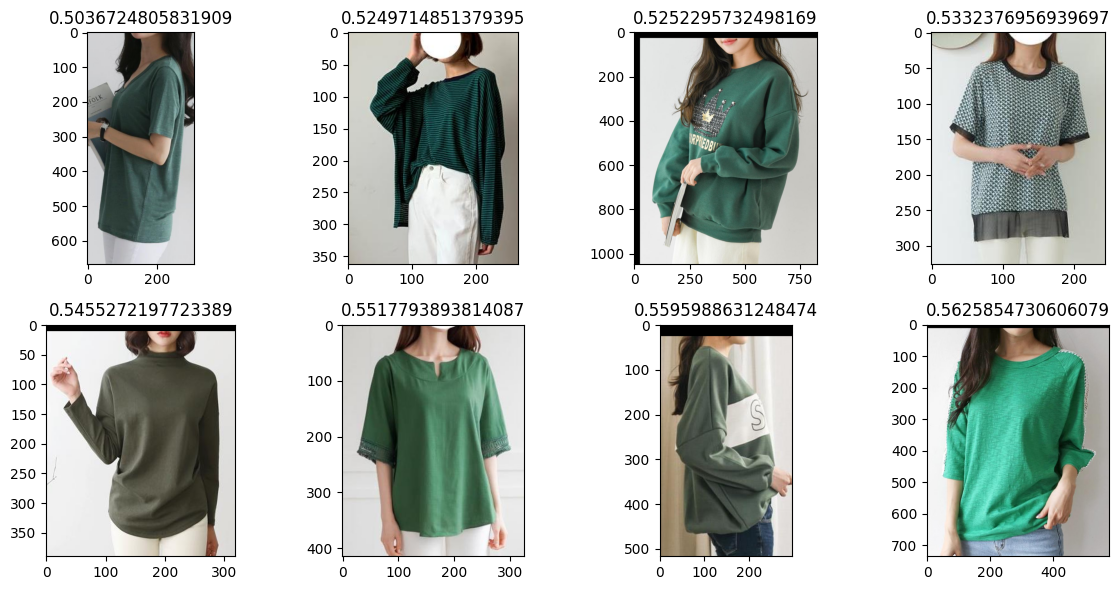

In [55]:
draw_image(image_list, dist_list)